<a href="https://colab.research.google.com/github/estefanioesteve10-source/coletData/blob/main/coletData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. O Papel de cada Biblioteca
Antes de codar, entenda a "função" de cada ferramenta no nosso time:

**Urllib**: O nosso "navegador" via código. Ele vai buscar os dados na internet.

**Pandas**: A nossa planilha inteligente. Organiza e limpa os dados.

**NumPy**: O motor matemático. Faz cálculos pesados de forma eficiente.

**Matplotlib**: O nosso artista. Transforma números em gráficos visuais.

#2. Importação e Coleta de Dados (urllib)
Vamos acessar a API do Sistema Gerenciador de Séries Temporais (SGS) do Banco Central.

In [1]:
import urllib.request
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL da API para o IPCA (Índice Nacional de Preços ao Consumidor Amplo)
# Código 433 é o IPCA mensal
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json"

# Usando urllib para abrir a conexão e ler os dados
with urllib.request.urlopen(url) as response:
    dados_brutos = response.read()
    dados_json = json.loads(dados_brutos)

print(f"Coletamos {len(dados_json)} registros com sucesso!")

Coletamos 555 registros com sucesso!


#3. Estruturação e Limpeza (pandas)
Os dados chegam como uma lista de dicionários. Vamos transformar isso em um **DataFrame** para facilitar a vida.

In [2]:
# Criar o DataFrame
df = pd.DataFrame(dados_json)

# Converter a coluna data para o formato datetime do pandas
df['data'] = pd.to_datetime(df['data'], dayfirst=True)

# Converter a coluna valor para float (número decimal)
df['valor'] = df['valor'].astype(float)

# Vamos focar apenas nos últimos 2 anos (24 meses)
df_recente = df.tail(24).copy()

print(df_recente.head())

          data  valor
531 2024-04-01   0.38
532 2024-05-01   0.46
533 2024-06-01   0.21
534 2024-07-01   0.38
535 2024-08-01  -0.02


#4. Processamento Matemático (**numpy**)
Aqui vamos usar o NumPy para calcular métricas estatísticas rápidas sobre a inflação do período selecionado.

In [3]:
# Transformar a coluna de valores em um array NumPy
valores_np = df_recente['valor'].to_numpy()

media_inflacao = np.mean(valores_np)
max_inflacao = np.max(valores_np)
min_inflacao = np.min(valores_np)

print(f"Estatísticas dos últimos 24 meses:")
print(f"Média Mensal: {media_inflacao:.2f}%")
print(f"Pico de Inflação: {max_inflacao:.2f}%")
print(f"Mínima de Inflação: {min_inflacao:.2f}%")

Estatísticas dos últimos 24 meses:
Média Mensal: 0.39%
Pico de Inflação: 1.31%
Mínima de Inflação: -0.11%


#5. Visualização de Dados (**matplotlib**)
Agora, vamos transformar esses números em um gráfico de linha para identificar tendências.

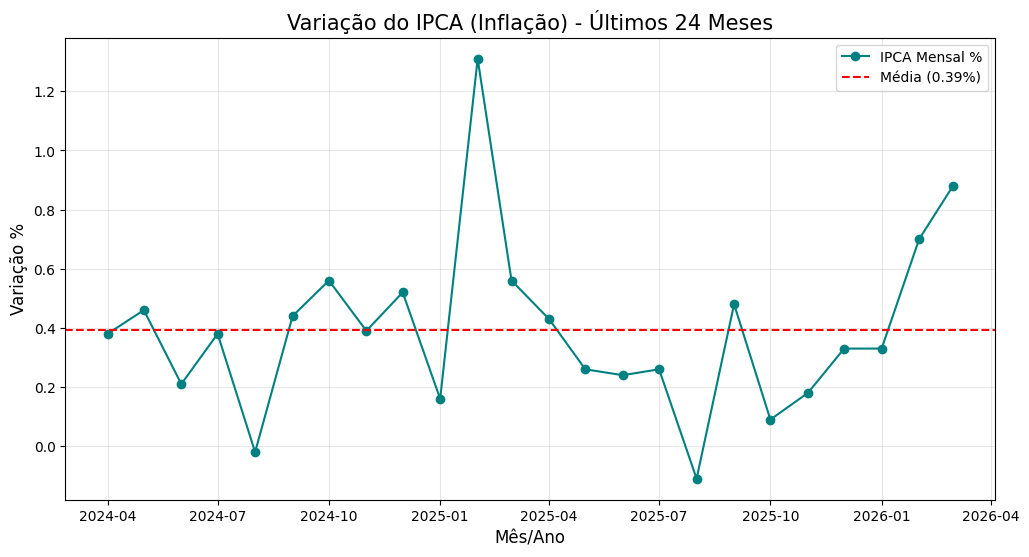

In [4]:
# Configurar o tamanho da imagem
plt.figure(figsize=(12, 6))

# Criar o gráfico de linha
plt.plot(df_recente['data'], df_recente['valor'],
         marker='o', linestyle='-', color='teal', label='IPCA Mensal %')

# Adicionar uma linha horizontal com a média (usando o valor do NumPy)
plt.axhline(y=media_inflacao, color='red', linestyle='--', label=f'Média ({media_inflacao:.2f}%)')

# Títulos e Legendas
plt.title('Variação do IPCA (Inflação) - Últimos 24 Meses', fontsize=15)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Variação %', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Exibir
plt.show()